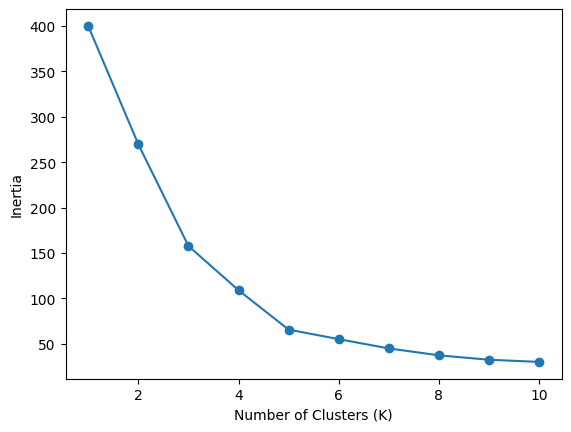

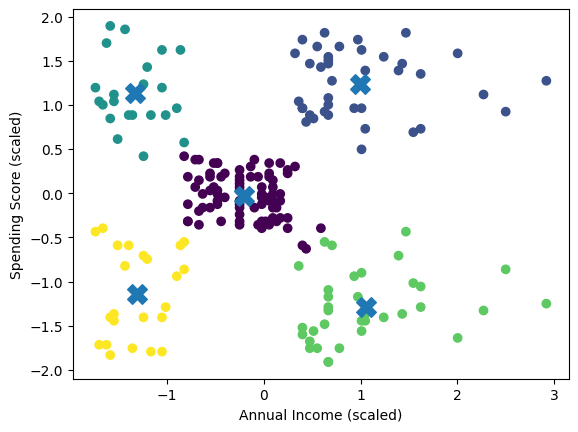

S.ASWIN 24BAD014
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

df = df.drop(columns=["CustomerID"])

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X')
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print("S.ASWIN 24BAD014")
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.groupby("Cluster").mean())

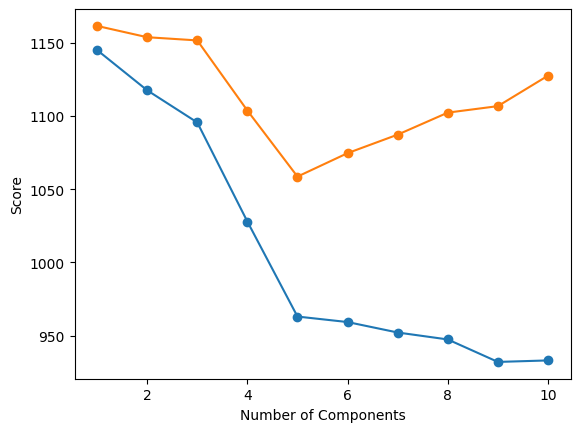

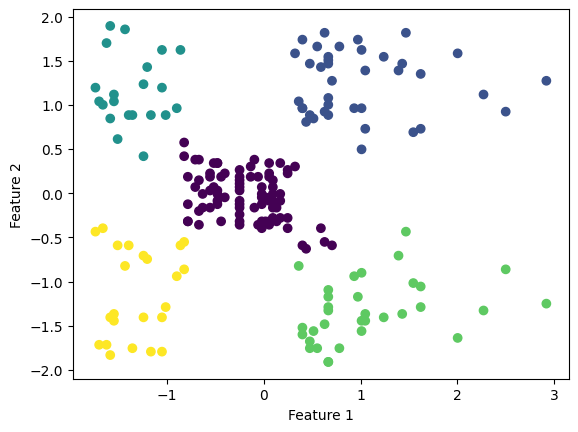

S.ASWIN 24BAD014
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


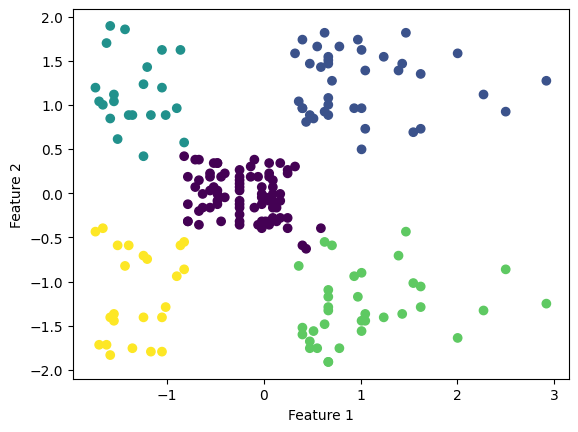

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  GMM_Cluster
0    Male   19                  15                      39            4
1    Male   21                  15                      81            2
2  Female   20                  16                       6            4
3  Female   23                  16                      77            2
4  Female   31                  17                      40            4
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

df = df.drop(columns=["CustomerID"])

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(K_range, aic, marker='o')
plt.plot(K_range, bic, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.show()

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
clusters = gmm.predict(X_scaled)

df["GMM_Cluster"] = clusters

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("S.ASWIN 24BAD014")
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
k_clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(df.head())
print(probs[:5])